
# Hysteresis Analysis for Forward/Reverse I-V

This notebook builds hysteresis-focused visualizations from cleaned I-V data:

1. **A(T)**: enclosed hysteresis area vs temperature  
2. **Delta plot**: $\Delta V(I)=V_{fwd}(I)-V_{rev}(I)$ at fixed/representative temperatures  
3. **$I_c$ split**: $I_{c,fwd}(T)$ vs $I_{c,rev}(T)$  
4. **4-panel figure** for publication

All inputs are read from `Processed_data/analysis_inputs/all_cleaned_iv.csv`.
Outputs are saved to `Report/reports/analysis_figures/`.


In [1]:

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['font.size'] = 11


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / 'Processed_data').exists() and (p / 'Report').exists():
            return p
    raise FileNotFoundError('Cannot find project root containing Processed_data/ and Report/.')


PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / 'Processed_data' / 'analysis_inputs' / 'all_cleaned_iv.csv'
FIG_DIR = PROJECT_ROOT / 'Report' / 'reports' / 'analysis_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CSV_PATH:', CSV_PATH)
print('FIG_DIR:', FIG_DIR)


PROJECT_ROOT: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device
CSV_PATH: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Processed_data/analysis_inputs/all_cleaned_iv.csv
FIG_DIR: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures


In [2]:

df = pd.read_csv(CSV_PATH)

# normalize temperature column
def parse_temp_to_k(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors='coerce')
    return pd.to_numeric(s.astype(str).str.extract(r'([+-]?\d+(?:\.\d+)?)', expand=False), errors='coerce')

if 'temp' in df.columns:
    Tcol = 'temp'
elif 'T' in df.columns:
    Tcol = 'T'
else:
    raise ValueError(f'No temperature column found. Columns={list(df.columns)}')

for c in ['I', 'V', 'direction']:
    if c not in df.columns:
        raise ValueError(f'Missing required column: {c}')

work = df[['I', 'V', 'direction', Tcol]].copy()
work['T_K'] = parse_temp_to_k(work[Tcol])
work['I'] = pd.to_numeric(work['I'], errors='coerce')
work['V'] = pd.to_numeric(work['V'], errors='coerce')
work['direction'] = work['direction'].astype(str).str.lower()

if 'monotonic_keep' in df.columns:
    keep = df['monotonic_keep'].fillna(False).astype(bool)
    work = work.loc[keep].copy()

work = work.dropna(subset=['I', 'V', 'T_K'])
work = work[work['direction'].isin(['forward', 'reverse'])].copy()

temps = np.sort(work['T_K'].unique())
print('Rows used:', len(work))
print('Temperatures:', len(temps), temps[:6], '...', temps[-6:])
print(work['direction'].value_counts())


Rows used: 23675
Temperatures: 27 [ 2  3  4  5  8 10] ... [ 85  88  90  95 100 110]
direction
reverse    11996
forward    11679
Name: count, dtype: int64


In [3]:

def compress_curve(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sort by x and collapse duplicate x with median y."""
    o = np.argsort(x)
    x = x[o]
    y = y[o]
    d = pd.DataFrame({'x': x, 'y': y}).groupby('x', as_index=False)['y'].median()
    return d['x'].to_numpy(), d['y'].to_numpy()


def build_hysteresis_at_T(df_T: pd.DataFrame, n_grid: int = 500):
    d_f = df_T[df_T['direction'] == 'forward']
    d_r = df_T[df_T['direction'] == 'reverse']
    if len(d_f) < 20 or len(d_r) < 20:
        return None

    If, Vf = compress_curve(d_f['I'].to_numpy(float), d_f['V'].to_numpy(float))
    Ir, Vr = compress_curve(d_r['I'].to_numpy(float), d_r['V'].to_numpy(float))

    i_min = max(np.min(If), np.min(Ir))
    i_max = min(np.max(If), np.max(Ir))
    if not np.isfinite(i_min) or not np.isfinite(i_max) or i_max <= i_min:
        return None

    I_grid = np.linspace(i_min, i_max, n_grid)
    Vf_i = np.interp(I_grid, If, Vf)
    Vr_i = np.interp(I_grid, Ir, Vr)
    dV = Vf_i - Vr_i

    area_signed = float(np.trapezoid(dV, I_grid))
    area_abs = float(np.trapezoid(np.abs(dV), I_grid))

    return {
        'I': I_grid,
        'Vf': Vf_i,
        'Vr': Vr_i,
        'dV': dV,
        'A_signed': area_signed,
        'A_abs': area_abs,
    }


def extract_ic_abs(I: np.ndarray, V: np.ndarray, v_threshold: float = 1e-3, smooth_window: int = 11) -> float:
    """Estimate |Ic| from first crossing of |V| >= threshold over increasing |I|."""
    x = np.abs(I)
    y = np.abs(V)
    o = np.argsort(x)
    x = x[o]
    y = y[o]

    y_s = pd.Series(y).rolling(window=smooth_window, center=True, min_periods=1).median().to_numpy()
    idx = np.where(y_s >= v_threshold)[0]
    if len(idx) == 0:
        return np.nan

    k = int(idx[0])
    if k == 0:
        return float(x[0])

    x0, x1 = float(x[k-1]), float(x[k])
    y0, y1 = float(y_s[k-1]), float(y_s[k])
    if y1 == y0:
        return x1
    frac = (v_threshold - y0) / (y1 - y0)
    frac = float(np.clip(frac, 0.0, 1.0))
    return x0 + frac * (x1 - x0)


def fit_power_law_area(T: np.ndarray, A: np.ndarray):
    """Fit A ~ (T* - T)^beta by scanning T* and linear fitting in log space."""
    m = np.isfinite(T) & np.isfinite(A) & (A > 0)
    T = np.asarray(T[m], float)
    A = np.asarray(A[m], float)
    if len(T) < 6:
        return None

    # focus near transition tail (upper temperature half)
    q = np.quantile(T, 0.55)
    tail = T >= q
    Tt = T[tail]
    At = A[tail]
    if len(Tt) < 4:
        return None

    tmax = float(np.max(Tt))
    best = None
    for Tstar in np.linspace(tmax + 0.1, tmax + 25.0, 400):
        x = Tstar - Tt
        if np.any(x <= 0):
            continue
        lx = np.log(x)
        ly = np.log(At)
        p = np.polyfit(lx, ly, 1)
        beta, lnC = float(p[0]), float(p[1])
        yhat = beta * lx + lnC
        ss_res = float(np.sum((ly - yhat) ** 2))
        ss_tot = float(np.sum((ly - np.mean(ly)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        if np.isfinite(r2) and (best is None or r2 > best['r2']):
            best = {'Tstar': Tstar, 'beta': beta, 'lnC': lnC, 'r2': r2}

    return best


In [4]:

curves = {}
rows = []
for T in np.sort(work['T_K'].unique()):
    dT = work[np.isclose(work['T_K'], T)]
    obj = build_hysteresis_at_T(dT, n_grid=500)
    if obj is None:
        continue
    Ic_f = extract_ic_abs(obj['I'], obj['Vf'], v_threshold=1e-3)
    Ic_r = extract_ic_abs(obj['I'], obj['Vr'], v_threshold=1e-3)

    curves[float(T)] = obj
    rows.append({
        'T_K': float(T),
        'A_signed': obj['A_signed'],
        'A_abs': obj['A_abs'],
        'Ic_fwd': Ic_f,
        'Ic_rev': Ic_r,
        'Ic_split_abs': np.abs(Ic_f - Ic_r) if np.isfinite(Ic_f) and np.isfinite(Ic_r) else np.nan,
    })

metrics = pd.DataFrame(rows).sort_values('T_K').reset_index(drop=True)
print('Temperatures with valid forward+reverse hysteresis curves:', len(metrics))
display(metrics.head())


Temperatures with valid forward+reverse hysteresis curves: 27


,T_K,A_signed,A_abs,Ic_fwd,Ic_rev,Ic_split_abs
0,2.0,0.001821,0.001843,0.059737,0.061277,0.001540
1,3.0,0.001887,0.001891,0.059739,0.060980,0.001241
2,4.0,0.001865,0.001870,0.059736,0.060977,0.001241
3,5.0,0.001802,0.001806,0.059738,0.060976,0.001238
4,8.0,0.001874,0.001879,0.059741,0.060974,0.001233


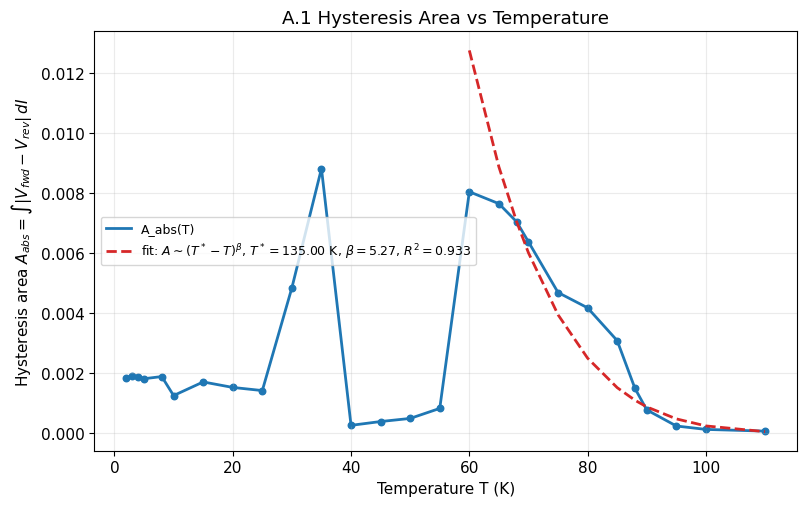

saved: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures/hysteresis_area_vs_temp.png


In [5]:

# A.1: area-vs-temperature
fit = fit_power_law_area(metrics['T_K'].to_numpy(), metrics['A_abs'].to_numpy())

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(metrics['T_K'], metrics['A_abs'], '-', lw=2.0, color='tab:blue', label='A_abs(T)')
ax.scatter(metrics['T_K'], metrics['A_abs'], s=22, color='tab:blue')
ax.set_xlabel('Temperature T (K)')
ax.set_ylabel(r'Hysteresis area $A_{abs} = \int |V_{fwd}-V_{rev}| \, dI$')
ax.set_title('A.1 Hysteresis Area vs Temperature')

if fit is not None:
    Tstar, beta, lnC, r2 = fit['Tstar'], fit['beta'], fit['lnC'], fit['r2']
    tail_mask = metrics['T_K'] >= np.quantile(metrics['T_K'], 0.55)
    T_tail = metrics.loc[tail_mask, 'T_K'].to_numpy()
    A_fit = np.exp(lnC) * np.power(np.clip(Tstar - T_tail, 1e-9, None), beta)
    ax.plot(T_tail, A_fit, '--', color='tab:red', lw=2,
            label=rf'fit: $A\sim(T^*-T)^\beta$, $T^*={Tstar:.2f}$ K, $\beta={beta:.2f}$, $R^2={r2:.3f}$')

ax.legend(loc='best', fontsize=9)
plt.tight_layout()
out = FIG_DIR / 'hysteresis_area_vs_temp.png'
fig.savefig(out, dpi=220)
plt.show()
print('saved:', out)


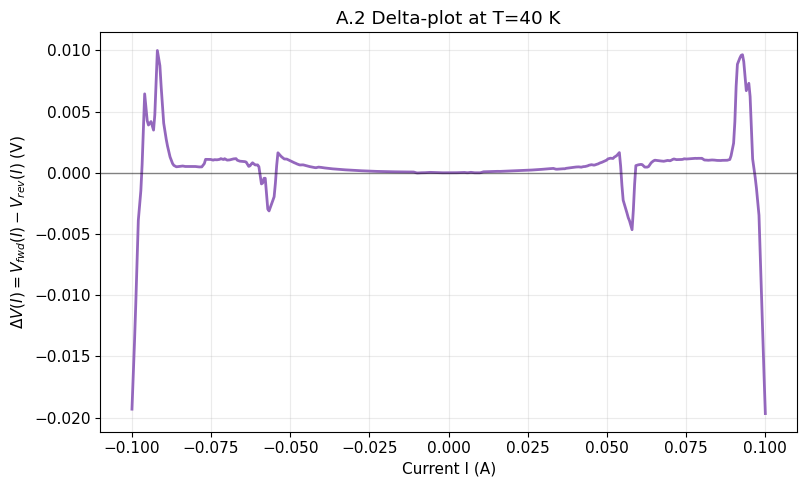

saved: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures/hysteresis_delta_fixedT.png


In [6]:

# A.2: delta-plot at a fixed temperature
if len(metrics) == 0:
    raise RuntimeError('No valid metrics to plot.')

target_T = 40.0
T_fixed = float(metrics.iloc[np.argmin(np.abs(metrics['T_K'] - target_T))]['T_K'])
obj = curves[T_fixed]

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(obj['I'], obj['dV'], color='tab:purple', lw=2)
ax.axhline(0.0, color='k', lw=1, alpha=0.45)
ax.set_xlabel('Current I (A)')
ax.set_ylabel(r'$\Delta V(I)=V_{fwd}(I)-V_{rev}(I)$ (V)')
ax.set_title(f'A.2 Delta-plot at T={T_fixed:.0f} K')
plt.tight_layout()
out = FIG_DIR / 'hysteresis_delta_fixedT.png'
fig.savefig(out, dpi=220)
plt.show()
print('saved:', out)


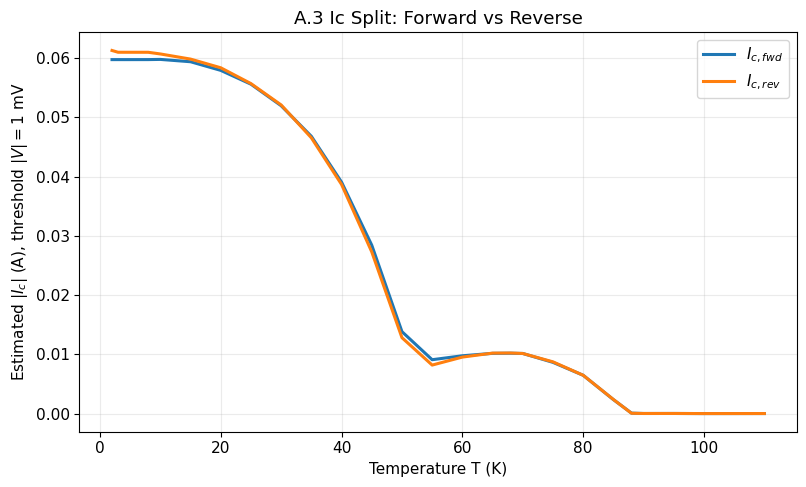

saved: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures/hysteresis_ic_split.png


In [7]:

# A.3: Ic_fwd(T) vs Ic_rev(T)
fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(metrics['T_K'], metrics['Ic_fwd'], '-', lw=2.2, color='tab:blue', label=r'$I_{c,fwd}$')
ax.plot(metrics['T_K'], metrics['Ic_rev'], '-', lw=2.2, color='tab:orange', label=r'$I_{c,rev}$')
ax.set_xlabel('Temperature T (K)')
ax.set_ylabel(r'Estimated $|I_c|$ (A), threshold $|V|=1$ mV')
ax.set_title('A.3 Ic Split: Forward vs Reverse')
ax.legend(loc='best')
plt.tight_layout()
out = FIG_DIR / 'hysteresis_ic_split.png'
fig.savefig(out, dpi=220)
plt.show()
print('saved:', out)


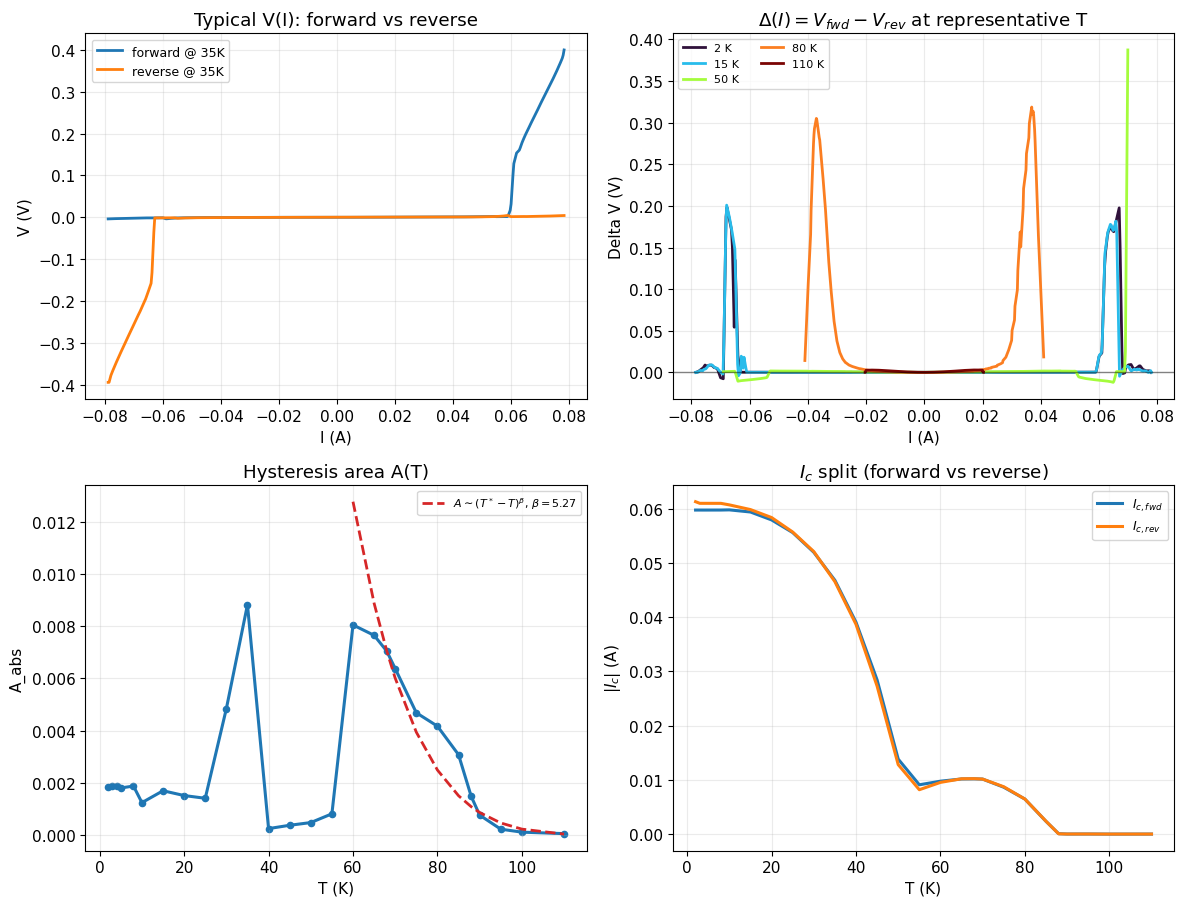

saved: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures/hysteresis_4panel.png


In [8]:

# A.4: publication 4-panel

def pick_rep_temps(Tvals, k=5):
    Tvals = np.array(sorted(Tvals), dtype=float)
    if len(Tvals) <= k:
        return Tvals.tolist()
    idx = np.linspace(0, len(Tvals)-1, k).round().astype(int)
    idx = np.unique(idx)
    return Tvals[idx].tolist()

T_rep = pick_rep_temps(metrics['T_K'].to_numpy(), k=5)
T_typical = float(metrics.iloc[np.argmax(metrics['A_abs'])]['T_K'])
obj_typ = curves[T_typical]

fig, axes = plt.subplots(2, 2, figsize=(12, 9.2))

# upper-left: typical VI overlay
ax = axes[0,0]
ax.plot(obj_typ['I'], obj_typ['Vf'], color='tab:blue', lw=2, label=f'forward @ {T_typical:.0f}K')
ax.plot(obj_typ['I'], obj_typ['Vr'], color='tab:orange', lw=2, label=f'reverse @ {T_typical:.0f}K')
ax.set_title('Typical V(I): forward vs reverse')
ax.set_xlabel('I (A)')
ax.set_ylabel('V (V)')
ax.legend(fontsize=9)

# upper-right: delta curves for representative temperatures
ax = axes[0,1]
cmap = plt.get_cmap('turbo')
for i, T in enumerate(T_rep):
    d = curves[float(T)]
    ax.plot(d['I'], d['dV'], lw=2, color=cmap(i / max(1, len(T_rep)-1)), label=f'{T:.0f} K')
ax.axhline(0.0, color='k', lw=1, alpha=0.45)
ax.set_title(r'$\Delta(I)=V_{fwd}-V_{rev}$ at representative T')
ax.set_xlabel('I (A)')
ax.set_ylabel('Delta V (V)')
ax.legend(fontsize=8, ncol=2)

# lower-left: area vs T
ax = axes[1,0]
ax.plot(metrics['T_K'], metrics['A_abs'], '-', lw=2.2, color='tab:blue')
ax.scatter(metrics['T_K'], metrics['A_abs'], s=20, color='tab:blue')
if fit is not None:
    Tstar, beta, lnC = fit['Tstar'], fit['beta'], fit['lnC']
    tail_mask = metrics['T_K'] >= np.quantile(metrics['T_K'], 0.55)
    T_tail = metrics.loc[tail_mask, 'T_K'].to_numpy()
    A_fit = np.exp(lnC) * np.power(np.clip(Tstar - T_tail, 1e-9, None), beta)
    ax.plot(T_tail, A_fit, '--', color='tab:red', lw=2,
            label=rf'$A\sim(T^*-T)^\beta$, $\beta={beta:.2f}$')
    ax.legend(fontsize=8)
ax.set_title('Hysteresis area A(T)')
ax.set_xlabel('T (K)')
ax.set_ylabel('A_abs')

# lower-right: Ic split
ax = axes[1,1]
ax.plot(metrics['T_K'], metrics['Ic_fwd'], '-', lw=2.2, color='tab:blue', label=r'$I_{c,fwd}$')
ax.plot(metrics['T_K'], metrics['Ic_rev'], '-', lw=2.2, color='tab:orange', label=r'$I_{c,rev}$')
ax.set_title(r'$I_c$ split (forward vs reverse)')
ax.set_xlabel('T (K)')
ax.set_ylabel(r'$|I_c|$ (A)')
ax.legend(fontsize=9)

plt.tight_layout()
out = FIG_DIR / 'hysteresis_4panel.png'
fig.savefig(out, dpi=260)
plt.show()
print('saved:', out)


In [9]:

# Export numeric metrics for paper/reproducibility
metrics_out = FIG_DIR / 'hysteresis_metrics_by_temperature.csv'
metrics.to_csv(metrics_out, index=False)
print('saved:', metrics_out)

metrics


saved: /Users/pirin/Desktop/Lab_summer_research_BSCCO_device/Report/reports/analysis_figures/hysteresis_metrics_by_temperature.csv


,T_K,A_signed,A_abs,Ic_fwd,Ic_rev,Ic_split_abs
0,2.0,0.001821,0.001843,0.059737,0.061277,1.539981e-03
1,3.0,0.001887,0.001891,0.059739,0.060980,1.240938e-03
2,4.0,0.001865,0.001870,0.059736,0.060977,1.240769e-03
3,5.0,0.001802,0.001806,0.059738,0.060976,1.237935e-03
4,8.0,0.001874,0.001879,0.059741,0.060974,1.232528e-03
5,10.0,0.001233,0.001244,0.059772,0.060692,9.200920e-04
6,15.0,0.001687,0.001699,0.059380,0.059826,4.462833e-04
7,20.0,0.001504,0.001516,0.057922,0.058360,4.385796e-04
8,25.0,0.001385,0.001411,0.055593,0.055692,9.916771e-05
9,30.0,0.004830,0.004842,0.051958,0.052090,1.320503e-04
